In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
bank_analyst = pd.read_csv('Bank_marketing_Dataset.csv')
bank_analyst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   V1      45211 non-null  int64 
 1   V2      45211 non-null  object
 2   V3      45211 non-null  object
 3   V4      45211 non-null  object
 4   V5      45211 non-null  object
 5   V6      45211 non-null  int64 
 6   V7      45211 non-null  object
 7   V8      45211 non-null  object
 8   V9      45211 non-null  object
 9   V10     45211 non-null  int64 
 10  V11     45211 non-null  object
 11  V12     45211 non-null  int64 
 12  V13     45211 non-null  int64 
 13  V14     45211 non-null  int64 
 14  V15     45211 non-null  int64 
 15  V16     45211 non-null  object
 16  Class   45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


In [4]:
bank_analyst.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [5]:
column_mapping = {
    'V1': 'age', 'V2': 'job', 'V3': 'marital', 'V4': 'education',
    'V5': 'default', 'V6': 'balance', 'V7': 'housing', 'V8': 'loan',
    'V9': 'contact', 'V10': 'day', 'V11': 'month', 'V12': 'duration',
    'V13': 'campaign', 'V14': 'pdays', 'V15': 'previous', 'V16': 'poutcome',
    'Class': 'subscribed'
}
bank_analyst = bank_analyst.rename(columns=column_mapping)


print(bank_analyst['subscribed'].value_counts())

subscribed
1    39922
2     5289
Name: count, dtype: int64


In [6]:

bank_analyst['subscribed'] = bank_analyst['subscribed'].map({1: 'no', 2: 'yes'})

In [7]:
bank_analyst['subscribed'] = bank_analyst['subscribed'].map({1: 'no', 2: 'yes'})

# pdays = -1 no es un missing, es "nunca contactado antes"
bank_analyst['contacted_before'] = bank_analyst['pdays'].apply(lambda x: 'no' if x == -1 else 'yes')

# bins de edad, la relación con la conversión no es lineal
bank_analyst['age_group'] = pd.cut(bank_analyst['age'], bins=[17, 25, 35, 50, 65, 100],
                             labels=['18-25', '26-35', '36-50', '51-65', '65+'])

bank_analyst['subscribed'].value_counts(normalize=True) * 100

Series([], Name: proportion, dtype: float64)

In [8]:
tasa_base = (bank_analyst['subscribed'] == 'yes').mean() * 100
print(f'Tasa de conversión global: {tasa_base:.1f}%')

Tasa de conversión global: 0.0%


In [9]:
def tasa_conversion(df, col, min_n=100):
    """Tasa de conversión y volumen por categoría, filtrando grupos muy chicos."""
    tabla = (df.groupby(col, observed=True)['subscribed']
               .agg(total='count', conversion=lambda x: (x == 'yes').mean() * 100)
               .query('total >= @min_n')
               .sort_values('conversion', ascending=False))
    return tabla

tasa_conversion(bank_analyst, 'job')

,total,conversion
job,,


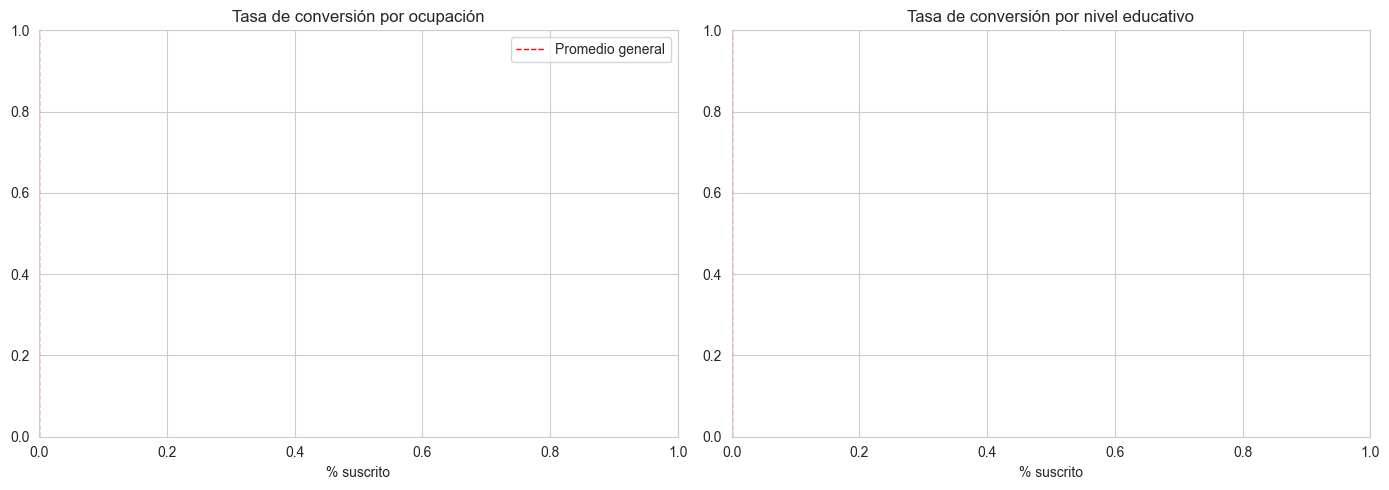

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

job_rates = tasa_conversion(bank_analyst, 'job')
sns.barplot(x=job_rates['conversion'], y=job_rates.index, ax=axes[0], palette='crest')
axes[0].set_title('Tasa de conversión por ocupación')
axes[0].set_xlabel('% suscrito')
axes[0].axvline(tasa_base, color='red', ls='--', lw=1, label='Promedio general')
axes[0].legend()

edu_rates = tasa_conversion(bank_analyst, 'education')
sns.barplot(x=edu_rates['conversion'], y=edu_rates.index, ax=axes[1], palette='crest')
axes[1].set_title('Tasa de conversión por nivel educativo')
axes[1].set_xlabel('% suscrito')
axes[1].axvline(tasa_base, color='red', ls='--', lw=1)

plt.tight_layout()
plt.savefig('conversion_job_education.png', dpi=150, bbox_inches='tight')
plt.show()